# Tutorial: Phase 1 Feature Engineering

Audience:
- Teams implementing handcrafted features for the classical ML baseline.

Prerequisites:
- Understanding of color histograms, grayscale texture analysis, and feature vectors.

Objective:
- Explain and inspect the HSV histogram, LBP, and GLCM features used in Phase 1.


## Outline

1. Setup and data discovery
2. Choose a sample image
3. Inspect color histogram features
4. Inspect LBP and GLCM texture features
5. Build a sample feature matrix
6. Summarize why these features matter for skin conditions


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 140)
SEED = 42


/Users/vaishnavverma/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/gp/0qsbr0x11d315dt15fl17c940000gn/T/matplotlib-hat2nkps because there was an issue with the default path (/Users/vaishnavverma/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


In [2]:
CANDIDATE_DATA_DIRS = [
    PROJECT_ROOT / 'dataset',
    PROJECT_ROOT / 'data' / 'raw' / 'Multi-Class Skin Condition Image Dataset (MSC-6)',
]
DATA_DIR = next((path for path in CANDIDATE_DATA_DIRS if path.exists()), CANDIDATE_DATA_DIRS[0])
CANDIDATE_OUTPUT_DIRS = [
    PROJECT_ROOT / 'outputs' / 'phase1_baseline_msc6',
    PROJECT_ROOT / 'outputs' / 'phase1_baseline',
]
OUTPUT_DIR = next((path for path in CANDIDATE_OUTPUT_DIRS if path.exists()), CANDIDATE_OUTPUT_DIRS[0])
IMAGE_SIZE = (224, 224)
TEST_SIZE = 0.2
RANDOM_STATE = 42
SAMPLE_FEATURE_ROWS = 64
SIZE_SCAN_LIMIT = 1000
print('Using DATA_DIR:', DATA_DIR)
print('Using OUTPUT_DIR:', OUTPUT_DIR)

from skimage.feature import local_binary_pattern

from src.skin_analysis.data import discover_dataset_records, load_and_preprocess_image
from src.skin_analysis.features import (
    extract_color_histogram,
    extract_features,
    extract_glcm_features,
    extract_lbp_histogram,
)


Using DATA_DIR: /Users/vaishnavverma/Downloads/Hybrid-Dermatologist/data/raw/Multi-Class Skin Condition Image Dataset (MSC-6)
Using OUTPUT_DIR: /Users/vaishnavverma/Downloads/Hybrid-Dermatologist/outputs/phase1_baseline_msc6


Using sample label: rosacea
Discovered files: 8823


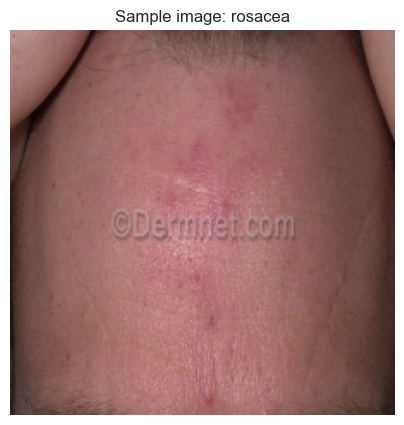

In [3]:
records_df, skipped_df, label_mapping = discover_dataset_records(DATA_DIR)
preferred_label = 'rosacea' if 'rosacea' in set(records_df['label']) else records_df.iloc[0]['label']
example_row = records_df[records_df['label'] == preferred_label].iloc[0]
loaded = load_and_preprocess_image(example_row['path'], image_size=IMAGE_SIZE)
example_image, _ = loaded

print(f'Using sample label: {example_row["display_label"]}')
print(f'Discovered files: {len(records_df)}')

example_rgb = cv2.cvtColor((example_image * 255).astype(np.uint8), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5, 5))
plt.imshow(example_rgb)
plt.title(f'Sample image: {example_row["display_label"]}')
plt.axis('off')
plt.show()


In [4]:
color_features = extract_color_histogram(example_image, hist_bins=32)
lbp_features = extract_lbp_histogram(example_image, lbp_points=24, lbp_radius=3)
glcm_features = extract_glcm_features(example_image)
combined_features = extract_features(example_image)

print('Color histogram length:', len(color_features))
print('LBP histogram length:', len(lbp_features))
print('GLCM feature length:', len(glcm_features))
print('Combined feature length:', len(combined_features))


Color histogram length: 96
LBP histogram length: 26
GLCM feature length: 32
Combined feature length: 154


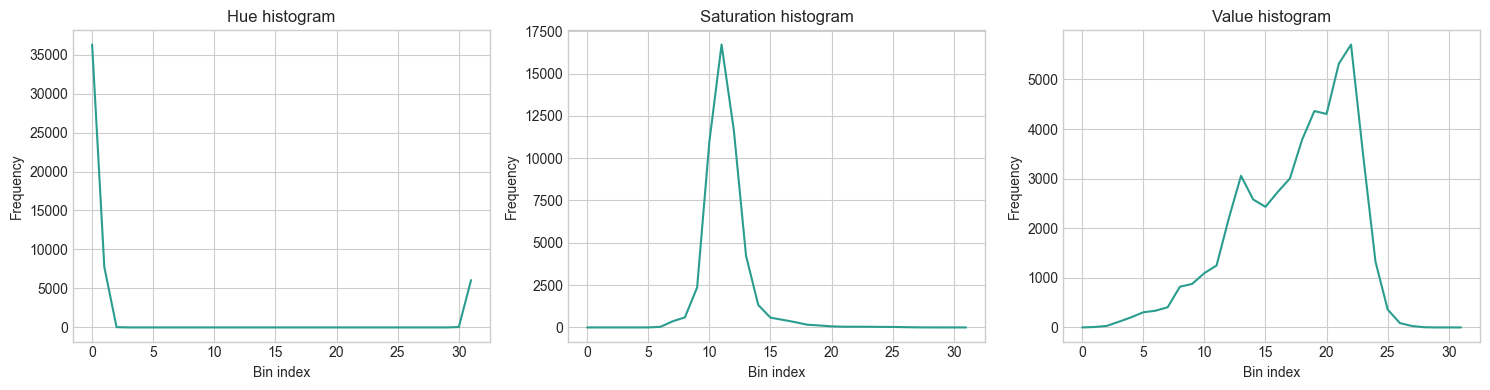

In [5]:
image_uint8 = (example_image * 255).astype(np.uint8)
hsv_image = cv2.cvtColor(image_uint8, cv2.COLOR_BGR2HSV)
channel_names = ['Hue', 'Saturation', 'Value']
channel_ranges = [(0, 180), (0, 256), (0, 256)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (name, channel_range) in enumerate(zip(channel_names, channel_ranges)):
    channel_hist = cv2.calcHist([hsv_image], [idx], None, [32], channel_range).flatten()
    axes[idx].plot(channel_hist, color='#2a9d8f')
    axes[idx].set_title(f'{name} histogram')
    axes[idx].set_xlabel('Bin index')
    axes[idx].set_ylabel('Frequency')
plt.tight_layout()
plt.show()


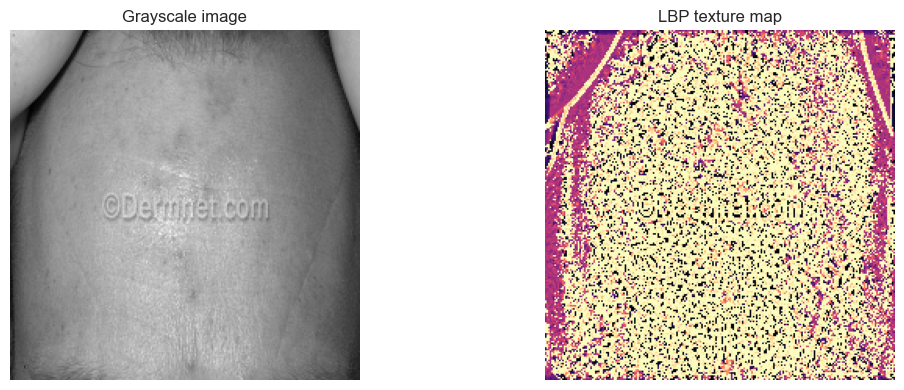

First 10 GLCM features: [50.7874 61.7751 33.6783 54.6415 81.8021 61.7751 56.1446 54.6415  0.2196
  0.2023]


In [6]:
gray_image = cv2.cvtColor(image_uint8, cv2.COLOR_BGR2GRAY)
lbp_map = local_binary_pattern(gray_image, P=24, R=3, method='uniform')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(gray_image, cmap='gray')
axes[0].set_title('Grayscale image')
axes[0].axis('off')
axes[1].imshow(lbp_map, cmap='magma')
axes[1].set_title('LBP texture map')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print('First 10 GLCM features:', np.round(glcm_features[:10], 4))


In [7]:
sample_records = records_df.head(SAMPLE_FEATURE_ROWS)
sample_vectors = []
for row in sample_records.itertuples(index=False):
    loaded = load_and_preprocess_image(row.path, image_size=IMAGE_SIZE)
    if loaded is None:
        continue
    image_bgr, _ = loaded
    sample_vectors.append(extract_features(image_bgr))

sample_matrix = np.vstack(sample_vectors)
print('Sample feature matrix shape:', sample_matrix.shape)
feature_df = pd.DataFrame(sample_matrix[:, :10], columns=[f'feature_{i:03d}' for i in range(10)])
feature_df['label'] = sample_records.iloc[: len(feature_df)]['display_label'].to_list()
display(feature_df.head())


Sample feature matrix shape: (64, 154)


,feature_000,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,feature_008,feature_009,label
0,0.003593,0.288554,0.913179,0.279395,0.062275,0.015957,0.020521,0.009289,0.007380,0.006312,normal
1,0.066101,0.161433,0.939520,0.293203,0.007546,0.004774,0.001817,0.000862,0.001170,0.000308,normal
2,0.209261,0.943955,0.193975,0.019281,0.000755,0.000377,0.000189,0.000126,0.000189,0.000063,normal
3,0.356572,0.822669,0.382607,0.077449,0.014703,0.011191,0.001311,0.000421,0.000749,0.000375,normal
4,0.394066,0.908257,0.120124,0.015750,0.006487,0.016879,0.005067,0.003292,0.009004,0.002130,normal


## Why These Features Matter

- HSV color histograms are useful for rosacea and dark spots because color shifts and redness are key visual cues.
- LBP is useful for eczema and wrinkles because local texture patterns capture dryness, roughness, and fine structural variation.
- GLCM adds complementary texture statistics such as contrast, homogeneity, energy, and correlation.
- This notebook keeps the demonstration sample-sized, while the full pipeline applies the same feature logic to the entire dataset.
